# Initial cleaning experiments

Exploring the missing values in the dataset

In [1]:
import pandas as pd

In [2]:
raw_df = pd.read_csv('uds_data.csv')

In [3]:
raw_df.shape

(558553, 198)

Currently 558553 rows with 198 columns

In [4]:
missing_values = raw_df[raw_df.isna().any(axis=1)]

In [5]:
missing_values.isna().sum()

no_show           0
age               0
GENDER            0
RACE              0
ETHNICITY         0
              ...  
c5_COI_met    99471
r_ED_met      99471
r_HE_met      99471
r_SE_met      99471
r_COI_met     99471
Length: 198, dtype: int64

From the Null column-wise sum the data within each joined index does not have Nulls and the main contributor for nulls is the left join on the CHOC data, concluding that there are no Nulls in the CHOC data provided

In [6]:
missing_svi = missing_values[missing_values['RPL_THEME1'].isna()]

In [7]:
missing_svi.isna().sum()

no_show           0
age               0
GENDER            0
RACE              0
ETHNICITY         0
              ...  
c5_COI_met    30977
r_ED_met      30977
r_HE_met      30977
r_SE_met      30977
r_COI_met     30977
Length: 198, dtype: int64

4 rows of the data have RPL_THEME1 and 4 as Nulls and I have decided to Null the entire SVI index columns for those 4 entries

In [8]:
missing_coi = missing_values[missing_values['r_HE_nat'].isna()]

In [9]:
missing_coi.isna().sum()

no_show           0
age               0
GENDER            0
RACE              0
ETHNICITY         0
              ...  
c5_COI_met    99168
r_ED_met      99168
r_HE_met      99168
r_SE_met      99168
r_COI_met     99168
Length: 198, dtype: int64

The Null counts for rows with just SVI values missing are the same for COI and SVI columns, meaning that missing SVI is a subset of missing COI, allowing us to parition the data into 3 cases:
1. Data with only the CHOC columns
2. Data with CHOC and SVI columns
3. Data with CHOC, SVI and COI columns

In [10]:
only_choc = raw_df[raw_df['RPL_THEME1'].isna()].dropna(axis=1)

In [11]:
choc_svi = raw_df[raw_df['r_HE_nat'].isna() & ~raw_df['RPL_THEME1'].isna()].dropna(axis=1)

In [12]:
choc_svi_coi = raw_df[~raw_df['r_HE_nat'].isna() & ~raw_df['RPL_THEME1'].isna()].dropna(axis=1)

Ensuring that the partition did not lose any data the sum of the partitions should equal the whole

In [13]:
only_choc.shape[0] + choc_svi.shape[0] + choc_svi_coi.shape[0] == raw_df.shape[0]

True

## Vizualizing Partitions

In [14]:
import matplotlib.pyplot as plt

def plot_data_partitions(sizes, names=['Partition A', 'Partition B', 'Partition C']):
    """
    Creates a side-by-side comparison of 3 data partitions.
    
    Parameters:
    sizes (list): A list of 3 numerical values representing the partition sizes.
    names (list): A list of 3 strings for the labels.
    """

    # Create the figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    colors = ['#5DADE2', '#48C9B0', '#F4D03F']

    # 1. Pie Chart (Relative Proportions)
    ax1.pie(sizes, labels=names, autopct='%1.1f%%', 
            colors=colors)
    ax1.set_title('Relative Proportion (%)')

    # 2. Bar Chart (Absolute Sizes)
    ax2.bar(names, sizes, color=colors)
    ax2.set_title('Absolute Partition Sizes')
    ax2.set_ylabel('Count / Number of Rows')

    plt.tight_layout()
    plt.show()

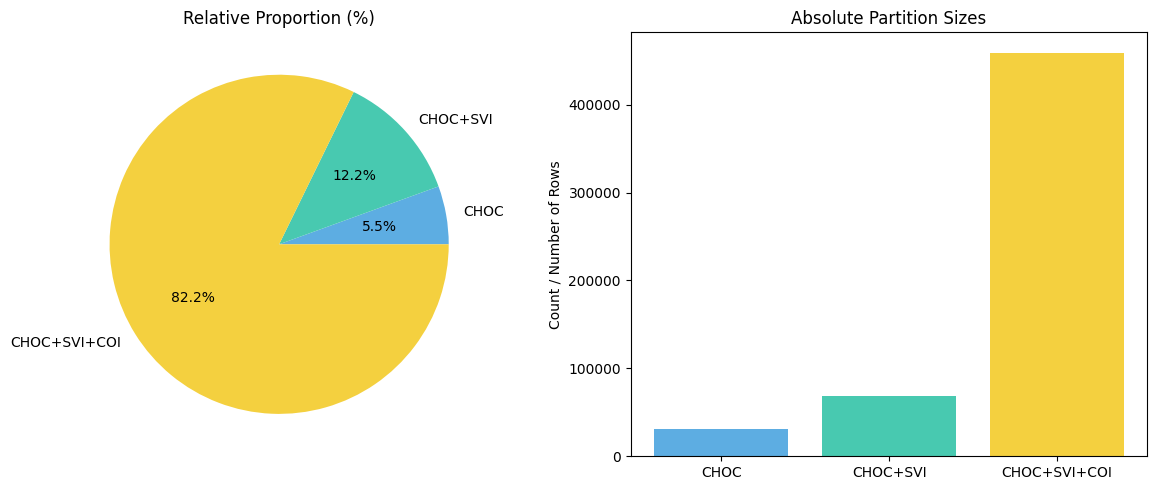

In [15]:
plot_data_partitions((only_choc.shape[0], choc_svi.shape[0], choc_svi_coi.shape[0]), ['CHOC', 'CHOC+SVI','CHOC+SVI+COI'])

The majority (82.2%) of the data has all three datasets joined on it and only 5.5% is missing all joined data. It is also important to see how the no-shows are distributed among the partitions

In [16]:
def plot_target_distribution(data_dict, title="Target Variable Proportion per Partition"):
    """
    Creates a stacked bar plot showing target class percentages per partition.
    
    data_dict: Dictionary where keys are partition names and values are 
               class counts. e.g., {'Train': {'Class A': 100, 'Class B': 20}}
    """
    # 1. Convert to DataFrame (Rows = Partitions, Columns = Classes)
    df = pd.DataFrame(data_dict).T
    
    # 2. Normalize to 100% (Proportions)
    # This ensures all bars are the same height so you can compare the ratio directly
    proportions = df.div(df.sum(axis=1), axis=0) * 100
    
    # 3. Plot
    ax = proportions.plot(kind='bar', stacked=True, figsize=(10, 6), 
                          color=['#3498DB', '#E67E22'])
    
    plt.title(title, fontsize=14, pad=20)
    plt.ylabel('Percentage (%)')
    plt.xlabel('Data Partitions')
    plt.xticks(rotation=0)
    plt.legend(title='Target Classes', bbox_to_anchor=(1.05, 1), loc='upper left')

    # 4. Add text labels to the segments
    for p in ax.patches:
        height = p.get_height()
        if height > 5: # Only show text if the segment is large enough
            ax.text(p.get_x() + p.get_width()/2, 
                    p.get_y() + height/2, 
                    f'{height:.1f}%', 
                    ha='center', va='center', 
                    color='white', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [17]:
choc_counts = only_choc['no_show'].value_counts()
choc_svi_counts = choc_svi['no_show'].value_counts()
choc_svi_coi_counts = choc_svi_coi['no_show'].value_counts()

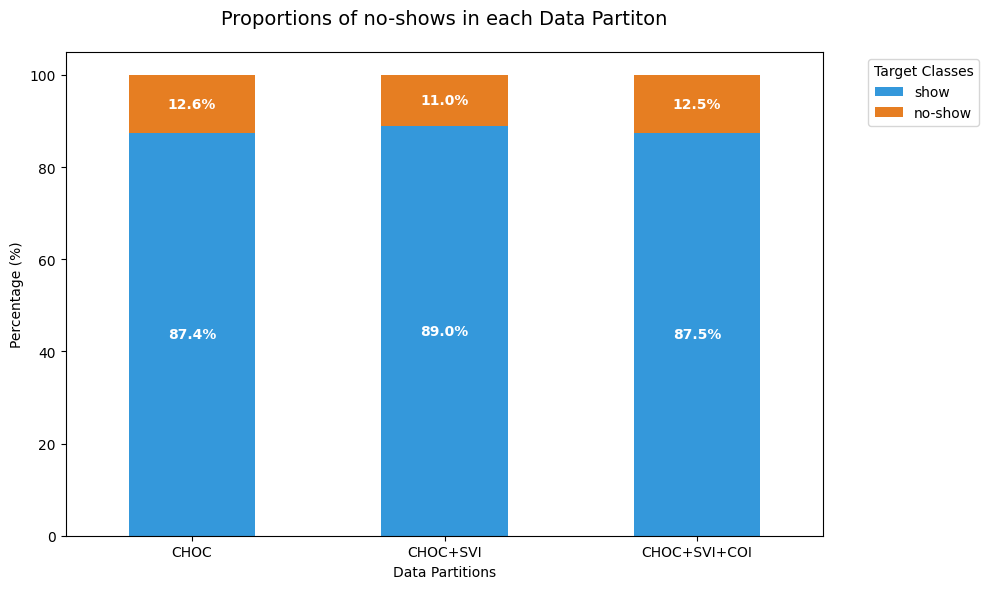

In [18]:

data = {
    'CHOC': {'show': choc_counts.iloc[0], 'no-show': choc_counts.iloc[1]},
    'CHOC+SVI': {'show': choc_svi_counts.iloc[0], 'no-show': choc_svi_counts.iloc[1]},
    'CHOC+SVI+COI': {'show': choc_svi_coi_counts.iloc[0], 'no-show': choc_svi_coi_counts.iloc[1]},
}
plot_target_distribution(data,title='Proportions of no-shows in each Data Partiton')

Interestingly the no-shows are almost exactly identically distributed across the three partitions.